In [1]:
# read data yearky in pickle file
import pickle
import sys
import os
import numpy as np
import torch 

maindir = os.getcwd()
sys.path.append(maindir+"/src")


# data = pickle.load('data_yearly.pickle')

with open('data_yearly.pickle', 'rb') as f:
    data = pickle.load(f)


data_anomaly_yearly = data['dic_data_yearly']
data_forced_response_yearly = data['dic_forced_response_yearly']

In [2]:
import netCDF4 as netcdf

# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

# reshape the data to (runs, time steps, latitude * longitude)
# data_test = data_test.reshape(data_test.shape[0], data_test.shape[1], -1)
# data_ground_truth_test = data_ground_truth_test.reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1], -1)

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  

In [3]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)

# Compute yearly averages for the test data
x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

# transform to pytorch tensors and reshape
x_test = torch.from_numpy(data_test).reshape(data_test.shape[0], data_test.shape[1], -1).to(torch.float32)
y_test = torch.from_numpy(data_ground_truth_test).reshape(data_ground_truth_test.shape[0], data_ground_truth_test.shape[1], -1).to(torch.float32)


x_test_yearly = torch.from_numpy(x_test_yearly).to(torch.float32).reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],x_test_yearly.shape[2]*x_test_yearly.shape[3])
y_test_yearly = torch.from_numpy(y_test_yearly).to(torch.float32).reshape(y_test_yearly.shape[0],y_test_yearly.shape[1],y_test_yearly.shape[2]*y_test_yearly.shape[3])

In [4]:
# get the data of the first climate model 
x_train_yearly = data_anomaly_yearly['CESM2']
y_train_yearly = data_forced_response_yearly['CESM2']

In [5]:
vars = {}
for idx_m, m in enumerate(data_anomaly_yearly.keys()):
    print(f'Processing model: {m}')
    vars[m] = torch.var(data_anomaly_yearly[m],dim=0)
    print(f'Noise level shape for {m}: {vars[m].shape}')

Processing model: CESM2
Noise level shape for CESM2: torch.Size([221, 10368])
Processing model: CanESM5
Noise level shape for CanESM5: torch.Size([221, 10368])
Processing model: MIROC-ES2L
Noise level shape for MIROC-ES2L: torch.Size([221, 10368])
Processing model: MIROC6
Noise level shape for MIROC6: torch.Size([221, 10368])
Processing model: MPI-ESM1-2-LR
Noise level shape for MPI-ESM1-2-LR: torch.Size([221, 10368])


In [9]:
# diffusion_spatiotemporal_ddpm.py
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple

# ----------------------------
# Utilities: time embedding
# ----------------------------
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for diffusion timesteps."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,) or scalar
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]  # (B, half)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1), value=0)
        return emb  # (B, dim)

def MLP(dim_in: int, hidden: int, dim_out: int, dropout: float = 0.0):
    return nn.Sequential(
        nn.Linear(dim_in, hidden),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(hidden, dim_out)
    )

# ----------------------------
# Basic block: Spatiotemporal ResBlock
# ----------------------------
class STResBlock(nn.Module):
    """
    Residual block that mixes temporal and spatial info.
    Uses 3D conv (T,H,W) with small temporal kernel.
    Modulates via time embedding (FiLM: scale & shift).
    """
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int, groups: int = 8):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch

        # 3D convs: (T,H,W)
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=(3,3,3), padding=(1,1,1))
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=(3,3,3), padding=(1,1,1))
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()

        # time embedding -> scale & shift
        self.time_mlp = MLP(time_emb_dim, out_ch*2, out_ch*2) if time_emb_dim > 0 else None

        # skip if channel mismatch
        if in_ch != out_ch:
            self.nin_shortcut = nn.Conv3d(in_ch, out_ch, kernel_size=1)
        else:
            self.nin_shortcut = nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: Optional[torch.Tensor]):
        # x: (B, C, T, H, W)
        h = self.conv1(x)
        h = self.norm1(h)
        if t_emb is not None:
            # time embedding -> (B, out_ch*2) -> scale, shift
            ts = self.time_mlp(t_emb)[:, :, None, None, None]  # (B, 2*out_ch, 1,1,1)
            scale, shift = ts.chunk(2, dim=1)
            h = h * (1 + scale) + shift
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.nin_shortcut(x)

# ----------------------------
# Downsample / Upsample
# ----------------------------
class Downsample3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # Downsample spatial dims by 2 (H,W). Keep T the same.
        self.op = nn.Conv3d(channels, channels, kernel_size=(1,4,4), stride=(1,2,2), padding=(0,1,1))

    def forward(self, x): return self.op(x)

class Upsample3D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.op = nn.ConvTranspose3d(channels, channels, kernel_size=(1,4,4), stride=(1,2,2), padding=(0,1,1))

    def forward(self, x): return self.op(x)

# ----------------------------
# 3D UNet
# ----------------------------
class UNet3D(nn.Module):
    """
    3D U-Net for spatio-temporal data.
    Input: (B, C, T, H, W)
    """
    def __init__(
        self,
        in_channels: int = 1,
        base_channels: int = 64,
        channel_mults: Tuple[int] = (1, 2, 4),
        num_res_blocks: int = 2,
        time_emb_dim: int = 128
    ):
        super().__init__()
        self.in_channels = in_channels
        self.base_channels = base_channels
        self.time_emb_dim = time_emb_dim

        # input conv
        self.init_conv = nn.Conv3d(in_channels, base_channels, kernel_size=3, padding=1)

        # time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim*4),
            nn.GELU(),
            nn.Linear(time_emb_dim*4, time_emb_dim)
        )

        # encoder
        self.downs = nn.ModuleList()
        ch = base_channels
        self.enc_channels = [ch]
        for mult in channel_mults:
            out_ch = base_channels * mult
            for _ in range(num_res_blocks):
                self.downs.append(STResBlock(ch, out_ch, time_emb_dim))
                ch = out_ch
                self.enc_channels.append(ch)
            # downsample
            self.downs.append(Downsample3D(ch))

        # middle
        self.mid = nn.Sequential(
            STResBlock(ch, ch, time_emb_dim),
            STResBlock(ch, ch, time_emb_dim)
        )

        # decoder
        self.ups = nn.ModuleList()
        for mult in reversed(channel_mults):
            # upsample
            self.ups.append(Upsample3D(ch))
            out_ch = base_channels * mult
            for _ in range(num_res_blocks):
                # input will be concat -> so in_ch = ch + skip_ch
                self.ups.append(STResBlock(ch + out_ch, out_ch, time_emb_dim))
                ch = out_ch

        # final conv
        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv3d(ch, in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # x: (B, C, T, H, W)
        assert x.ndim == 5
        b = x.shape[0]
        t_emb = self.time_mlp(t)  # (B, time_emb_dim)

        h = self.init_conv(x)
        hs = [h]

        # encoder
        for layer in self.downs:
            if isinstance(layer, STResBlock):
                h = layer(h, t_emb)
                hs.append(h)
            else:  # Downsample
                h = layer(h)

        # middle
        h = self.mid(h)

        # decoder
        for layer in self.ups:
            if isinstance(layer, Upsample3D):
                h = layer(h)
            else:  # STResBlock but expects concatenated skip
                skip = hs.pop()
                # concat along channel dim
                h = torch.cat([h, skip], dim=1)
                h = layer(h, t_emb)

        return self.final_conv(h)  # predicted noise (same shape as input)

# ----------------------------
# DDPM Noise schedule and helpers
# ----------------------------
def linear_beta_schedule(timesteps: int, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, timesteps)

class GaussianDiffusion:
    def __init__(self, model: nn.Module, timesteps: int = 1000, device: str = 'cuda'):
        self.model = model
        self.timesteps = timesteps
        self.device = device

        betas = linear_beta_schedule(timesteps).to(device)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer = {}
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1. / alphas)
        self.posterior_variance = betas
        self.posterior_variance[:-1] *= (1. - alphas_cumprod[:-1]) / (1. - alphas_cumprod[1:])  # not used for simple sampling
        self.posterior_variance[-1] = betas[-1] * 1 / (1. - alphas_cumprod[-1])

    def q_sample(self, x_start: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None):
        """
        Diffuse the data: sample x_t given x_0
        x_start: (B, C, T, H, W)
        t: (B,) timesteps indices in [0, timesteps-1]
        """
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1, 1)
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    def p_losses(self, x_start: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None):
        """
        Compute training loss: predict noise and take L2 between predicted and true noise.
        """
        if noise is None:
            noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise)
        # model predicts noise
        print(t)
        pred_noise = self.model(x_noisy, t)
        return F.mse_loss(pred_noise, noise)

    @torch.no_grad()
    def p_sample(self, x: torch.Tensor, t: int):
        """
        One reverse step (predict x_{t-1} given x_t)
        x: (B, C, T, H, W)
        t: int scalar timestep index
        """
        B = x.shape[0]
        t_tensor = torch.full((B,), t, device=x.device, dtype=torch.long)
        pred_noise = self.model(x, t_tensor)  # predicted noise
        beta_t = self.betas[t]
        alpha_t = self.alphas[t]
        alpha_cumprod_t = self.alphas_cumprod[t]
        alpha_cumprod_prev = self.alphas_cumprod[t-1] if t > 0 else torch.tensor(1., device=x.device)

        # predict x0
        coef1 = 1. / torch.sqrt(alpha_t)
        coef2 = (beta_t / torch.sqrt(1. - alpha_cumprod_t))
        x0_pred = coef1 * (x - coef2 * pred_noise)

        # compute mean of posterior q(x_{t-1} | x_t, x0_pred)
        posterior_mean_coef1 = (torch.sqrt(alpha_cumprod_prev) * beta_t) / (1. - alpha_cumprod_t)
        posterior_mean_coef2 = (torch.sqrt(alpha_t) * (1. - alpha_cumprod_prev)) / (1. - alpha_cumprod_t)
        posterior_mean = posterior_mean_coef1 * x0_pred + posterior_mean_coef2 * x

        if t > 0:
            noise = torch.randn_like(x)
            posterior_var = self.posterior_variance[t-1] if (t-1) < len(self.posterior_variance) else beta_t
            return posterior_mean + torch.sqrt(posterior_var) * noise
        else:
            return posterior_mean

    @torch.no_grad()
    def sample(self, shape: Tuple[int]):
        """
        Full sampling loop: start from Gaussian noise and iterate backwards.
        shape: (B, C, T, H, W)
        """
        device = next(self.model.parameters()).device
        x = torch.randn(shape, device=device)
        for t in reversed(range(self.timesteps)):
            x = self.p_sample(x, t)
        return x

# ----------------------------
# Example: creating model, diffusion and running forward
# ----------------------------
if __name__ == "__main__":
    # Example hyperparams
    B, C, T, H, W = 2, 1, 16, 32, 32  # small example
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model = UNet3D(in_channels=C, base_channels=32, channel_mults=(1,2,4), num_res_blocks=1, time_emb_dim=128)
    model.to(device)

    diffusion = GaussianDiffusion(model, timesteps=200, device=device)

    # dummy data
    x0 = torch.randn(B, C, T, H, W, device=device)

    # sample random timesteps per batch
    t = torch.randint(0, diffusion.timesteps, (B,), device=device).long()

    loss = diffusion.p_losses(x0, t)
    print("Loss:", loss.item())

    # quick sampling (will be slow)
    # out = diffusion.sample((B, C, T, H, W))
    # print("Sampled shape:", out.shape)


tensor([ 47, 138])


TypeError: forward() missing 1 required positional argument: 't_emb'

In [6]:
## code to generate corrupted data for each climate model
def generate_corrupted_data(data, noise_level=0.1, n_samples=10):
    """Generate corrupted data by adding Gaussian noise to the original data.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           noise_level: standard deviation of the Gaussian noise
       Return:
           corrupted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    noise = np.random.normal(0, noise_level, (n_samples, data.shape[1],data.shape[2]))

    # select a random sample from the training set using an index

    corrupted_data = data[0,:,:] + noise
    return corrupted_data

corrupted_data_tmp = generate_corrupted_data(y_train_yearly, noise_level=1.5*vars['CESM2'], n_samples=50)

print(f'Corrupted data shape: {corrupted_data_tmp.shape}')

Corrupted data shape: torch.Size([50, 221, 10368])


In [7]:
# import torch.nn as nn

# class ScoreNet(nn.Module):
#     def __init__(self, input_dim, hidden_dim=128, output_dim=None):
#         super().__init__()
#         if output_dim is None:
#             output_dim = input_dim
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, output_dim)
#         )

#     def forward(self, x):
#         return self.net(x)

In [8]:
# # score matching training
# dataloader = torch.utils.data.DataLoader(
#     (x_train_yearly,y_train_yearly), batch_size=32, shuffle=True
# )

# u = next(iter(dataloader))

# print(f'Input shape: {u[0].shape}, Target shape: {u[1].shape}')


# # train the score matching function
# score_net = ScoreNet(input_dim=u[0].shape[1], hidden_dim=128, output_dim=u[1].shape[1])
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(score_net.parameters(), lr=0.001)

# for epoch in range(10):
#     for x, y in dataloader:
#         optimizer.zero_grad()
#         output = score_net(x)
#         loss = criterion(output, torch.abs(y-x))
#         loss.backward()
#         optimizer.step()
    
#     if epoch % 10 == 0:
#         print(f'Epoch {epoch}, Loss: {loss.item()}')

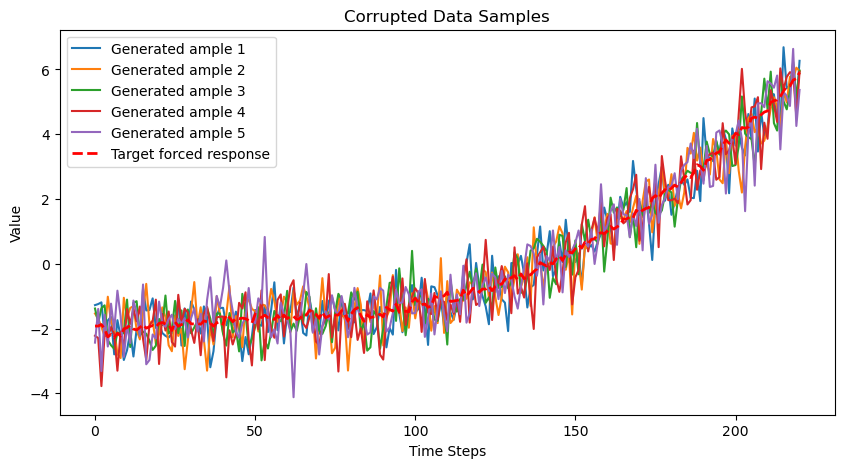

In [9]:
# plot some time series of the corrupted data
import matplotlib.pyplot as plt

idx_grid_cell = 100
plt.figure(figsize=(10, 5))
for i in range(corrupted_data_tmp.shape[0])[:5]:
    plt.plot(corrupted_data_tmp[i, :, idx_grid_cell], label=f'Generated ample {i+1}')

# for j in range(x_train_yearly.shape[0])[:5]:
#     plt.plot(x_train_yearly[j, :, idx_grid_cell], label=f'Training sample {j+1}', alpha=0.5)

plt.plot(y_train_yearly[0,:, idx_grid_cell], label='Target forced response', color='red', linewidth=2, linestyle='--')
plt.title('Corrupted Data Samples')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

In [10]:
from algorithms import ridge_regression, ridge_regression_low_rank

# transform the data for the ridge regression
x_tmp = x_train_yearly.reshape(x_train_yearly.shape[0]*x_train_yearly.shape[1], -1)
y_tmp = y_train_yearly.reshape(y_train_yearly.shape[0]*y_train_yearly.shape[1], -1)

# penalty parameters
lambda_tmp = 1000.0

# ridge regression
w_ridge = ridge_regression(x_tmp, y_tmp, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_tmp@w_ridge,full_matrices=False)

Loss function:  2461745.25


In [11]:
# define the rank
rank = 5

w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

In [12]:
# compute the ridge regression prediction 
y_pred = x_test_yearly@w_ridge

# compute the low rank ridge regression prediction
y_pred_low_rank = x_test_yearly@w_ridge_low_rank

# compute the mse between the prediction and the ground truth
rmse = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'RMSE Ridge Regression: {rmse}')
print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')

RMSE Ridge Regression: [0.21724398 0.23815152 0.48562115 0.25918385 0.2752391  0.11517038
 0.3268417  0.25263086 0.42665997 0.23860793]
RMSE Low Rank Ridge Regression: [0.21908386 0.23985052 0.4878017  0.2678492  0.28098407 0.12296852
 0.32902145 0.25567958 0.42507747 0.23863046]


In [13]:
# add the corrupted data in the training set to see if i can get any improvement
x_train_tmp =torch.cat((x_train_yearly, corrupted_data_tmp), dim=0)
y_train_tmp = torch.cat((y_train_yearly, y_train_yearly[:corrupted_data_tmp.shape[0],:,:]), dim=0)
# generate corrupted data with shift in


# reshape 
x_train_tmp = x_train_tmp.reshape(x_train_tmp.shape[0]*x_train_tmp.shape[1], -1).to(torch.float32)
y_train_tmp = y_train_tmp.reshape(y_train_tmp.shape[0]*y_train_tmp.shape[1], -1).to(torch.float32)

In [14]:
# penalty parameters
lambda_tmp = 1000.0

# ridge regression
w_ridge_new = ridge_regression(x_train_tmp, y_train_tmp, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_tmp@w_ridge_new,full_matrices=False)

Loss function:  2263699.0


In [15]:
# define the rank
rank = 5

w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

In [16]:
# test the values 
y_pred_new = x_test_yearly@w_ridge_new
y_pred_low_rank_new = x_test_yearly@w_ridge_low_rank

# compute the error of the prediction (with corrupted data)
rmse_new = torch.sqrt(torch.mean((y_pred_new - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_new = torch.sqrt(torch.mean((y_pred_low_rank_new - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()  

In [17]:
print(f'RMSE Ridge Regression: {rmse}')
print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')
print(f'RMSE Ridge Regression with Corrupted Data: {rmse_new}')
print(f'RMSE Low Rank Ridge Regression with Corrupted Data: {rmse_low_rank_new}') 

RMSE Ridge Regression: [0.21724398 0.23815152 0.48562115 0.25918385 0.2752391  0.11517038
 0.3268417  0.25263086 0.42665997 0.23860793]
RMSE Low Rank Ridge Regression: [0.21908386 0.23985052 0.4878017  0.2678492  0.28098407 0.12296852
 0.32902145 0.25567958 0.42507747 0.23863046]
RMSE Ridge Regression with Corrupted Data: [0.213298   0.2267041  0.45781583 0.2534495  0.26316777 0.1223205
 0.30444098 0.23699164 0.4216411  0.24473605]
RMSE Low Rank Ridge Regression with Corrupted Data: [0.21904497 0.23939936 0.48749167 0.26742464 0.2805335  0.12261076
 0.32865918 0.25543186 0.42509422 0.23877929]


In [18]:
# test the values (monthly data)

y_pred = x_test @ w_ridge
y_pred_low_rank = x_test @ w_ridge_low_rank
y_pred_new = x_test @ w_ridge_new
y_pred_low_rank_new = x_test @ w_ridge_low_rank


# compute the error 
rmse = torch.sqrt(torch.mean((y_pred - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_new = torch.sqrt(torch.mean((y_pred_new - y_test) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_new = torch.sqrt(torch.mean((y_pred_low_rank_new - y_test) ** 2,axis=(1,2))).detach().numpy()  

In [19]:
print(f'RMSE Ridge Regression (monthly data): {rmse}')
print(f'RMSE Low Rank Ridge Regression (monthly data): {rmse_low_rank}')
print(f'RMSE Ridge Regression with Corrupted Data (monthly data): {rmse_new}')
print(f'RMSE Low Rank Ridge Regression with Corrupted Data (monthly data): {rmse_low_rank_new}')

RMSE Ridge Regression (monthly data): [0.411698   0.44099557 0.7355354  0.46242785 0.47483397 0.3576274
 0.556874   0.39828917 0.46087068 0.45070168]
RMSE Low Rank Ridge Regression (monthly data): [0.4109871  0.43981525 0.7381212  0.46595222 0.47732088 0.35966757
 0.5569436  0.3965017  0.45439613 0.45035964]
RMSE Ridge Regression with Corrupted Data (monthly data): [0.40646383 0.42740571 0.7100938  0.45314366 0.4578758  0.35235688
 0.53829604 0.3830793  0.4507705  0.4514791 ]
RMSE Low Rank Ridge Regression with Corrupted Data (monthly data): [0.4109871  0.43981525 0.7381212  0.46595222 0.47732088 0.35966757
 0.5569436  0.3965017  0.45439613 0.45035964]


In [20]:
data_anomaly_yearly['CESM2'].shape, data_forced_response_yearly['CESM2'].shape

(torch.Size([50, 221, 10368]), torch.Size([50, 221, 10368]))

In [21]:
w_ridge_per_model = {}
w_ridge_low_rank_per_model = {}

# train a model on each climate model
for m in data_anomaly_yearly.keys():
    print(f'Processing model: {m}')
    x_train_yearly_tmp = data_anomaly_yearly[m]
    y_train_yearly_tmp = data_forced_response_yearly[m]

    corrupted_data_tmp = generate_corrupted_data(y_train_yearly_tmp, noise_level=1.5*vars[m], n_samples=50)

    # add the corrupted data in the training set to see if i can get any improvement
    x_train_tmp =torch.cat((x_train_yearly_tmp, corrupted_data_tmp), dim=0)
    y_train_corrupted_tmp = y_train_yearly_tmp[0,:,:].unsqueeze(0).repeat(corrupted_data_tmp.shape[0], 1,1)
    y_train_tmp = torch.cat((y_train_yearly_tmp, y_train_corrupted_tmp), dim=0)

    # reshape the data for the ridge regression
    x_tmp = x_train_tmp.reshape(x_train_tmp.shape[0]*x_train_tmp.shape[1], -1).to(torch.float32)
    y_tmp = y_train_tmp.reshape(y_train_tmp.shape[0]*y_train_tmp.shape[1], -1).to(torch.float32) 

    # penalty parameters
    lambda_tmp = 1000.0
    
    # ridge regression
    w_ridge = ridge_regression(x_tmp, y_tmp, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)  
    
    # low rank regression
    U,S,V = torch.linalg.svd(x_tmp@w_ridge,full_matrices=False) 

    # define the rank
    rank = 5
    w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

    # save the weights
    w_ridge_per_model[m] = w_ridge
    w_ridge_low_rank_per_model[m] = w_ridge_low_rank

    # compute the ridge regression prediction
    y_pred = x_test_yearly@w_ridge

    # compute the low rank ridge regression prediction
    y_pred_low_rank = x_test_yearly@w_ridge_low_rank

    # compute the mse between the prediction and the ground truth
    rmse = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()  
    print(f'RMSE Ridge Regression for {m}: {rmse}')
    print(f'RMSE Low Rank Ridge Regression for {m}: {rmse_low_rank}')



Processing model: CESM2


Loss function:  2265500.75
RMSE Ridge Regression for CESM2: [0.21382749 0.22624515 0.45457423 0.25602645 0.262781   0.12295622
 0.30433753 0.23653893 0.43564972 0.24504024]
RMSE Low Rank Ridge Regression for CESM2: [0.21527237 0.22804788 0.45655578 0.26448002 0.26897073 0.12828983
 0.30605286 0.23977673 0.43360728 0.24438359]
Processing model: CanESM5
Loss function:  3552616.25


KeyboardInterrupt: 

In [ ]:
# compute the training score for each climate model 

rmse_per_model = {}
rmse_low_rank_per_model = {}

for m in data_anomaly_yearly.keys():
    print(f'Processing model: {m}')
    x_train_yearly_tmp = data_anomaly_yearly[m]
    y_train_yearly_tmp = data_forced_response_yearly[m]

    # compute the ridge regression prediction
    y_pred = x_train_yearly_tmp@w_ridge_per_model[m]

    # compute the low rank ridge regression prediction
    y_pred_low_rank = x_train_yearly_tmp@w_ridge_low_rank_per_model[m]

    # compute the mse between the prediction and the ground truth
    rmse_per_model[m] = torch.max(torch.sqrt(torch.mean((y_pred - y_train_yearly_tmp) ** 2,axis=(1,2))))
    rmse_low_rank_per_model[m] = torch.max(torch.sqrt(torch.mean((y_pred_low_rank - y_train_yearly_tmp) ** 2,axis=(1,2))))
    print(f'RMSE Ridge Regression for {m}: {rmse_per_model[m]}')
    print(f'RMSE Low Rank Ridge Regression for {m}: {rmse_low_rank_per_model[m]}')

Processing model: CESM2
RMSE Ridge Regression for CESM2: 0.13527905941009521
RMSE Low Rank Ridge Regression for CESM2: 0.13961325585842133
Processing model: CanESM5
RMSE Ridge Regression for CanESM5: 0.20195303857326508
RMSE Low Rank Ridge Regression for CanESM5: 0.21298649907112122
Processing model: MIROC-ES2L
RMSE Ridge Regression for MIROC-ES2L: 0.1420510709285736
RMSE Low Rank Ridge Regression for MIROC-ES2L: 0.14704784750938416
Processing model: MIROC6
RMSE Ridge Regression for MIROC6: 0.12777963280677795
RMSE Low Rank Ridge Regression for MIROC6: 0.13263985514640808
Processing model: MPI-ESM1-2-LR
RMSE Ridge Regression for MPI-ESM1-2-LR: 0.13954323530197144
RMSE Low Rank Ridge Regression for MPI-ESM1-2-LR: 0.14798779785633087


In [ ]:
score = torch.tensor([rmse_per_model[m] for m in data_anomaly_yearly.keys()])
score_lr = torch.tensor([rmse_low_rank_per_model[m] for m in data_anomaly_yearly.keys()])

In [ ]:
# do some weighted predictions
weights = 1/score * torch.ones((len(w_ridge_per_model.keys()),), dtype=torch.float32)
weights = weights / torch.sum(weights)  # normalize the weights
weights_lr = 1/score_lr * torch.ones((len(w_ridge_low_rank_per_model.keys()),), dtype=torch.float32)
weights_lr = weights_lr / torch.sum(weights_lr)  # normalize the weights


# check if we use weights such as w['CanESM5'] = 1.0 since it gives the prediction
weights = torch.tensor([1.0 if m == 'CanESM5' else 0.0 for m in data_anomaly_yearly.keys()], dtype=torch.float32)
weights_lr = torch.tensor([1.0 if m == 'CanESM5' else 0.0 for m in data_anomaly_yearly.keys()], dtype=torch.float32)



# weights = 1/len(w_ridge_per_model.keys()) * torch.ones((len(w_ridge_per_model.keys()),), dtype=torch.float32)
# weights_lr = 1/len(w_ridge_low_rank_per_model.keys()) * torch.ones((len(w_ridge_low_rank_per_model.keys()),), dtype=torch.float32)

# weighted predictions
y_pred = x_test_yearly @ w_ridge
y_pred_low_rank = x_test_yearly @ w_ridge_low_rank
y_pred_weighted = torch.zeros_like(y_test_yearly)
y_pred_low_rank_weighted = torch.zeros_like(y_test_yearly)

for idx_m, m in enumerate(data_anomaly_yearly.keys()):
    print(f'Processing model: {m}')
    y_pred_weighted += weights[idx_m] * (x_test_yearly @ w_ridge_per_model[m])
    y_pred_low_rank_weighted += weights_lr[idx_m] * (x_test_yearly @ w_ridge_low_rank_per_model[m])

# compute the mse between the prediction and the ground truth
rmse_weighted = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_weight =  torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy() 


print(f'RMSE Ridge Regression: {rmse}')
print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')
print(f'RMSE Weighted Ridge Regression: {rmse_weighted}')
print(f'RMSE Weighted Low Rank Ridge Regression: {rmse_low_rank_weight}')

Processing model: CESM2
Processing model: CanESM5
Processing model: MIROC-ES2L
Processing model: MIROC6
Processing model: MPI-ESM1-2-LR
RMSE Ridge Regression: [0.13523176 0.2069561  0.37818345 0.28265586 0.21768534 0.21410258
 0.26251814 0.1944836  0.44215563 0.24725406]
RMSE Low Rank Ridge Regression: [0.14649124 0.2033485  0.38006422 0.28626487 0.22263175 0.21354526
 0.2607262  0.19396663 0.43860963 0.2460385 ]
RMSE Weighted Ridge Regression: [0.23493673 0.23112433 0.20135233 0.5086327  0.2360309  0.2203854
 0.26701668 0.22040334 0.4546694  0.26334935]
RMSE Weighted Low Rank Ridge Regression: [0.2246757  0.22911094 0.2129707  0.5039049  0.23914835 0.21752983
 0.25772512 0.21194074 0.44775844 0.25840744]


In [ ]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train   # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test

In [ ]:
# compute the distance of a sample to training data of each climate model
def compute_distance_to_training(x, data):   
    """Compute the distance of a sample to training data of each climate model.
       Args:
           x: pytorch tensor of shape (runs, time steps, latitude * longitude)
           data: dictionary of pytorch tensors, each of shape (runs, time steps, latitude * longitude)
       Return:
           distance: pytorch tensor of shape (runs, number of climate models)
    """
    distance = torch.zeros((x.shape[0], len(data.keys())), dtype=torch.float32)
    for idx_m, m in enumerate(data.keys()):
        print(f'Processing model: {m}')
        for i in range(x.shape[0]):
            distance[i, idx_m] = torch.mean((x[i,:,:] - data[m][:,years_test_idx_feature,:]) ** 2)
    return distance

In [ ]:
scores = compute_distance_to_training(x_test_yearly, data_forced_response_yearly)
scores = 1/ scores
# for each row, assign 1 for the max of the scores and 0 otherwise
# scores = torch.where(scores == torch.max(scores, dim=1, keepdim=True).values, 1.0, 0.0)
# normalize the scores  
print(scores)

weights = scores / torch.sum(scores, dim=1, keepdim=True)  # normalize the scores
weights_lr = scores / torch.sum(scores, dim=1, keepdim=True)  # normalize the scores

Processing model: CESM2
Processing model: CanESM5
Processing model: MIROC-ES2L
Processing model: MIROC6
Processing model: MPI-ESM1-2-LR
tensor([[0.8006, 0.2304, 0.9827, 0.6157, 0.9083],
        [0.8066, 0.2362, 1.0095, 0.6198, 0.8732],
        [0.6652, 0.2449, 0.7592, 0.5151, 0.6935],
        [0.5534, 0.2253, 0.6118, 0.4396, 0.5744],
        [0.8318, 0.2409, 1.0219, 0.6230, 0.9033],
        [0.8777, 0.2364, 1.0383, 0.6314, 0.9131],
        [0.7588, 0.2316, 0.8964, 0.5802, 0.8123],
        [0.8337, 0.2340, 1.0652, 0.6542, 0.9252],
        [0.8550, 0.2391, 1.0488, 0.6371, 0.9233],
        [0.7696, 0.2240, 0.9142, 0.5892, 0.8257]])


In [ ]:
# weighted predictions
y_pred = x_test_yearly @ w_ridge
y_pred_low_rank = x_test_yearly @ w_ridge_low_rank
y_pred_weighted = torch.zeros_like(y_test_yearly)
y_pred_low_rank_weighted = torch.zeros_like(y_test_yearly)

for idx_m, m in enumerate(data_anomaly_yearly.keys()):
    print(f'Processing model: {m}')
    for i in range(x_test_yearly.shape[0]):
        y_pred_weighted[i,:,:] += weights[i,idx_m] * (x_test_yearly[i,:,:] @ w_ridge_per_model[m])
        y_pred_low_rank_weighted[i,:,:] += weights_lr[i,idx_m] * (x_test_yearly[i,:,:] @ w_ridge_low_rank_per_model[m])

# compute the mse between the prediction and the ground truth
rmse_weighted = torch.sqrt(torch.mean((y_pred_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_weight =  torch.sqrt(torch.mean((y_pred_low_rank_weighted - y_test_yearly) ** 2,axis=(1,2))).detach().numpy() 


print(f'RMSE Ridge Regression: {rmse}')
print(f'RMSE Low Rank Ridge Regression: {rmse_low_rank}')
print(f'RMSE Weighted Ridge Regression: {rmse_weighted}')
print(f'RMSE Weighted Low Rank Ridge Regression: {rmse_low_rank_weight}')

Processing model: CESM2
Processing model: CanESM5
Processing model: MIROC-ES2L
Processing model: MIROC6
Processing model: MPI-ESM1-2-LR
RMSE Ridge Regression: [0.13523176 0.2069561  0.37818345 0.28265586 0.21768534 0.21410258
 0.26251814 0.1944836  0.44215563 0.24725406]
RMSE Low Rank Ridge Regression: [0.14649124 0.2033485  0.38006422 0.28626487 0.22263175 0.21354526
 0.2607262  0.19396663 0.43860963 0.2460385 ]
RMSE Weighted Ridge Regression: [0.1681011  0.18548627 0.3494288  0.29766652 0.20147872 0.18003005
 0.23414753 0.15831016 0.4435544  0.23802869]
RMSE Weighted Low Rank Ridge Regression: [0.17122403 0.18512079 0.3532794  0.3026157  0.20774435 0.18192498
 0.2347527  0.15997986 0.44070482 0.24035633]


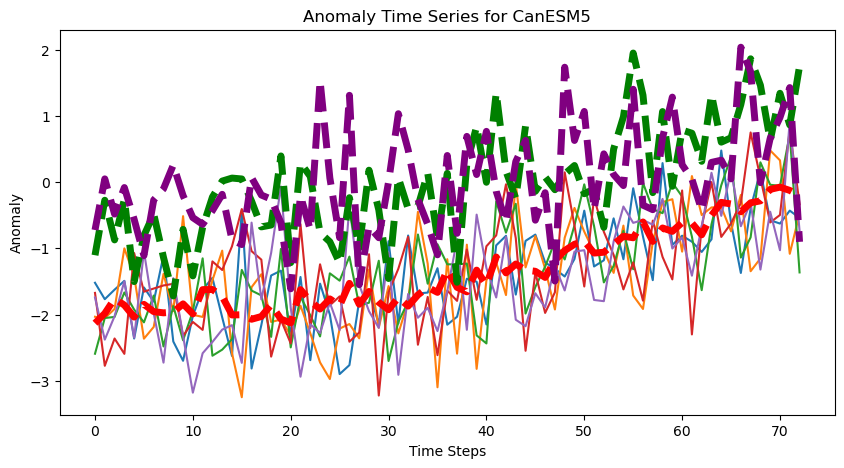

In [ ]:
# plot the time series of model CanESM5
import matplotlib.pyplot as plt

idx_grid_cell = 200
plt.figure(figsize=(10, 5))
for i in range(data_anomaly_yearly['CanESM5'].shape[0])[:5]:
    plt.plot(data_anomaly_yearly['CanESM5'][i, years_test_idx_feature, idx_grid_cell], label=f'Sample {i+1}')
plt.plot(data_forced_response_yearly['CanESM5'][0, years_test_idx_feature,idx_grid_cell], label='Target forced response', color='red', linewidth=5, linestyle='--')

plt.plot(x_test_yearly[2, :, idx_grid_cell], label='Test data', color='green', linewidth=5, linestyle='--')

plt.plot(x_test_yearly[0, :, idx_grid_cell], label='Test data', color='purple', linewidth=5, linestyle='--')

plt.title('Anomaly Time Series for CanESM5')
plt.xlabel('Time Steps')
plt.ylabel('Anomaly')
# plt.legend()
plt.show()

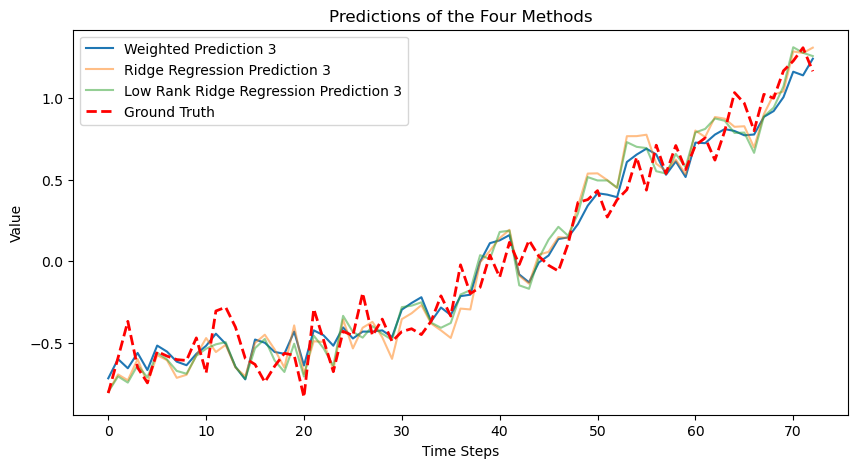

In [ ]:
# plot some time series of the predictions of the four methods
import matplotlib.pyplot as plt

idx_grid_cell = 100
idx_run = 2

plt.figure(figsize=(10, 5))
plt.plot(y_pred_weighted[idx_run, :, idx_grid_cell], label=f'Weighted Prediction {idx_run+1}')
plt.plot(y_pred[idx_run, :, idx_grid_cell], label=f'Ridge Regression Prediction {idx_run+1}', alpha=0.5)
plt.plot(y_pred_low_rank[idx_run, :, idx_grid_cell], label=f'Low Rank Ridge Regression Prediction {idx_run+1}', alpha=0.5)
plt.plot(y_test_yearly[idx_run,:, idx_grid_cell], label='Ground Truth', color='red', linewidth=2, linestyle='--')
plt.title('Predictions of the Four Methods')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

In [ ]:
import torch
import torch.nn as nn

# Simple MLP ScoreNet for multivariate time series
class TimeSeriesScoreNet(nn.Module):
    def __init__(self, time_steps, features, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),  # [batch, time_steps, features] -> [batch, time_steps * features]
            nn.Linear(time_steps * features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, time_steps * features)
        )
        self.time_steps = time_steps
        self.features = features

    def forward(self, x):
        out = self.net(x)
        return out.view(-1, self.time_steps, self.features)

# Diffusion Score Matching Model
class DiffusionScoreMatching(nn.Module):
    def __init__(self, score_net, sigma=0.1, alpha=0.01, T=10):
        super().__init__()
        self.score_net = score_net
        self.sigma = sigma
        self.alpha = alpha
        self.T = T

    def forward(self, x, y):
        # x: noisy input, y: clean target
        # Score matching loss (Denoising Score Matching)
        noise = (x - y)
        score = self.score_net(x)
        loss = ((score + noise) ** 2).mean()
        return loss

    def sample(self, batch_size):
        # Generate samples using Langevin dynamics
        x = torch.zeros(batch_size, self.score_net.time_steps, self.score_net.features)
        for _ in range(self.T):
            grad = self.score_net(x)
            x = x + self.alpha * grad + torch.sqrt(torch.tensor(2 * self.alpha)) * torch.randn_like(x)
        return x

# Example usage
batch_size, time_steps, features = 32, y_test_yearly.shape[1], y_test_yearly.shape[2]
score_net = TimeSeriesScoreNet(time_steps, features)
model = DiffusionScoreMatching(score_net)

# Dummy data
x = torch.randn(batch_size, time_steps, features)  # noisy
y = torch.randn(batch_size, time_steps, features)  # clean

# Training step
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = model(x, y)
loss.backward()
optimizer.step()

In [ ]:
def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = x[m]/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = y[m]/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, x[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, y[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train

# Merge training data for all models
# x_train_yearly, y_train_yearly = merge_training_data(data_anomaly_yearly, data_forced_response_yearly)

x_train_yearly = data_anomaly_yearly['CESM2']
y_train_yearly = data_forced_response_yearly['CESM2']

In [ ]:
# 2. Create DataLoader for batching
from torch.utils.data import DataLoader, TensorDataset

batch_size = 32
train_dataset = TensorDataset(x_train_yearly, y_train_yearly)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

time_steps = x_train_yearly.shape[1]  # Number of time steps
features = x_train_yearly.shape[2]  # Number of features (grid cells)

# 3. Initialize the model and optimizer
score_net = TimeSeriesScoreNet(time_steps, features)
model = DiffusionScoreMatching(score_net, sigma=0.1, alpha=0.01, T=100)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 50

# 4. Training loop
for epoch in range(epochs):
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = model(x_batch, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# ...existing code...

Epoch 1/50, Loss: 0.5944
Epoch 2/50, Loss: 0.4463
Epoch 3/50, Loss: 0.4463
Epoch 4/50, Loss: 0.4463
Epoch 5/50, Loss: 0.4463
Epoch 6/50, Loss: 0.4463
Epoch 7/50, Loss: 0.4463
Epoch 8/50, Loss: 0.4463
Epoch 9/50, Loss: 0.4463
Epoch 10/50, Loss: 0.4463
Epoch 11/50, Loss: 0.4463
Epoch 12/50, Loss: 0.4463
Epoch 13/50, Loss: 0.4463
Epoch 14/50, Loss: 0.4463
Epoch 15/50, Loss: 0.4463
Epoch 16/50, Loss: 0.4463
Epoch 17/50, Loss: 0.4462
Epoch 18/50, Loss: 0.4462
Epoch 19/50, Loss: 0.4462
Epoch 20/50, Loss: 0.4462
Epoch 21/50, Loss: 0.4462
Epoch 22/50, Loss: 0.4462
Epoch 23/50, Loss: 0.4462
Epoch 24/50, Loss: 0.4462
Epoch 25/50, Loss: 0.4462
Epoch 26/50, Loss: 0.4462
Epoch 27/50, Loss: 0.4462
Epoch 28/50, Loss: 0.4462
Epoch 29/50, Loss: 0.4462
Epoch 30/50, Loss: 0.4461
Epoch 31/50, Loss: 0.4461
Epoch 32/50, Loss: 0.4461
Epoch 33/50, Loss: 0.4461
Epoch 34/50, Loss: 0.4461
Epoch 35/50, Loss: 0.4461
Epoch 36/50, Loss: 0.4461
Epoch 37/50, Loss: 0.4461
Epoch 38/50, Loss: 0.4461
Epoch 39/50, Loss: 0.

In [ ]:
# generate samples using the trained model
num_samples = 10
samples = model.sample(num_samples)
# Reshape samples to match the original data shape
samples = samples.view(num_samples, time_steps, features)

print(samples)


tensor([[[ 3.0563e-01,  3.3001e-01, -2.2071e+00,  ...,  2.9446e+00,
          -1.0427e+00,  9.8746e-01],
         [-1.8051e+00, -2.3917e+00, -9.0395e-01,  ..., -2.8635e-01,
           1.5914e+00,  1.1846e+00],
         [ 6.8772e-01,  9.1475e-01, -5.0135e+00,  ...,  7.8188e-01,
          -2.0765e-01, -6.7919e-02],
         ...,
         [ 1.7605e+00, -1.5898e+00,  4.8001e-01,  ...,  1.3306e-01,
          -1.2179e+00, -3.8755e-01],
         [-1.4122e+00, -7.0812e-01, -1.1975e+00,  ...,  1.5310e+00,
          -2.6699e+00,  1.4439e+00],
         [ 7.9247e-02,  5.1778e-01, -5.4396e-01,  ..., -4.3862e+00,
          -1.9645e+00,  2.3694e+00]],

        [[-9.0765e-01, -7.5630e-01,  4.3114e-01,  ..., -2.5415e+00,
           9.1882e-01,  2.8693e+00],
         [ 6.7708e-01, -1.5800e+00,  1.7834e-01,  ..., -8.9697e-01,
          -7.6710e-01, -2.8621e+00],
         [ 5.3100e-01, -9.5848e-01, -1.2785e+00,  ..., -9.6806e-02,
           2.0255e+00, -3.1148e-01],
         ...,
         [-1.0950e+00,  7

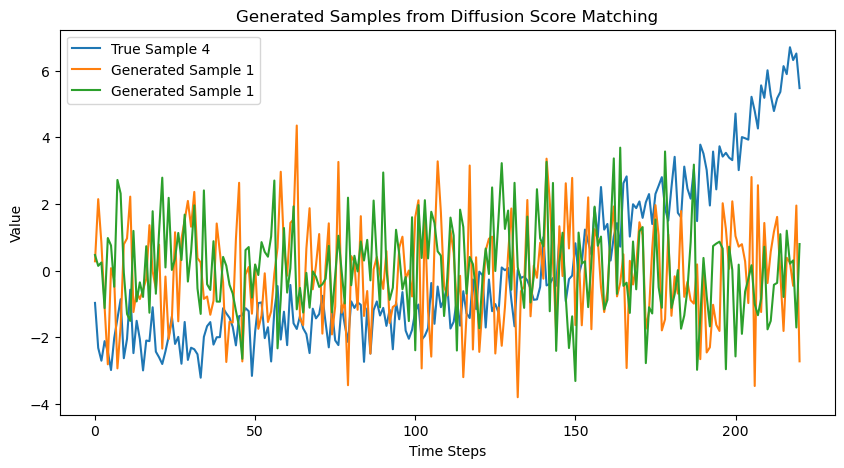

In [ ]:
# display some generated samples time series
import matplotlib.pyplot as plt

idx_grid_cell = 100
plt.figure(figsize=(10, 5))
plt.plot(x_train_yearly[0, :, idx_grid_cell].detach().numpy(), label=f'True Sample {i+1}')
plt.plot(samples[0, :, idx_grid_cell].detach().numpy(), label=f'Generated Sample 1')
plt.plot(samples[1, :, idx_grid_cell].detach().numpy(), label=f'Generated Sample 1')
# plt.plot(samples[1, :, idx_grid_cell].detach().numpy(), label=f'Generated Sample 2')
# plt.plot(samples[2, :, idx_grid_cell].detach().numpy(), label=f'Generated Sample 3')
# plt.plot(samples[3, :, idx_grid_cell].detach().numpy(), label=f'Generated Sample 4')
plt.title('Generated Samples from Diffusion Score Matching')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()